In [1]:
#REDGE REGRESSION AND LASSO
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv("C:/ADITYA CODING LAB/PYTHON/Machine Learning/session5/house_price.csv")

In [3]:
df.head()

,House_Area_sqft,House_Price_Lakh
0,550,46.96
1,600,54.24
2,650,54.24
3,700,61.16
4,750,58.40


In [4]:
df.shape

(35, 2)

In [5]:
# seperate dependent and independent variable
X=df[['House_Area_sqft']]
Y=df['House_Price_Lakh']

In [6]:
# train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42) # on this level it gives best values.

In [7]:
# scailing
ss=StandardScaler()

In [8]:
X_Train_Scaled=ss.fit_transform(X_train)
X_Test_Scaled=ss.transform(X_test)

<Axes: xlabel='House_Area_sqft', ylabel='House_Price_Lakh'>

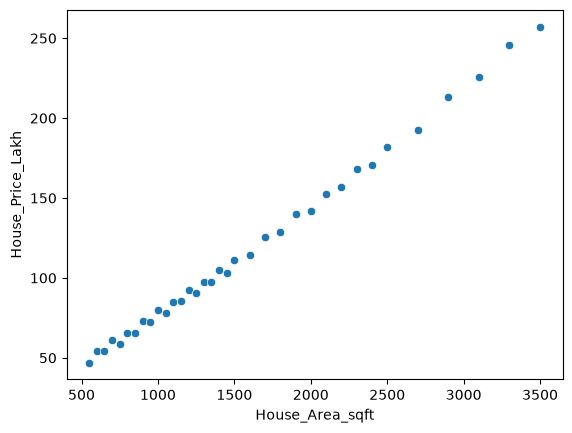

In [9]:
sns.scatterplot(x="House_Area_sqft",y="House_Price_Lakh",data=df)

In [10]:
# LinearRegression
lr=LinearRegression()

In [11]:
lr.fit(X_Train_Scaled,Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[61.25]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,117.4
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[5.29]


In [12]:
# training result/accuracy
lr.score(X_Train_Scaled,Y_train)

0.996896870623044

In [13]:
# testing accuracy
y_pred=lr.predict(X_Test_Scaled)

In [14]:
y_pred

array([161.39193076,  90.9339844 , 147.30034149, 126.16295758,
        97.97977904, 182.52931466, 112.07136831])

In [15]:
r2=r2_score(Y_test,y_pred)

In [16]:
r2

0.9906186267148098

In [17]:
#99% training acc and 99% testing acc it is best fit model
# if 99% training acc and 45% testing acc  = overfitting
# 45% training acc and 45% testing acc = underfitting